<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/04_rbi_inflation_tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

raw_macro_data = """Month,Headline_CPI,Food_Inflation,Repo_Rate
2024-01-01,5.10,8.30,6.50
2024-02-01,5.09,8.66,6.50
2024-03-01,4.85,8.52,6.50
2024-04-01,4.83,8.70,6.50
2024-05-01,4.75,8.69,6.50
2024-06-01,5.08,9.36,6.50
2024-07-01,3.54,5.42,6.50
2024-08-01,3.65,5.66,6.50
2024-09-01,5.49,9.24,6.50
2024-10-01,6.21,10.87,6.50
2024-11-01,5.55,9.15,6.50
2024-12-01,5.22,8.40,6.50
2025-01-01,4.31,6.10,6.50
2025-02-01,3.90,5.15,6.25
"""

with open("rbi_cpi_data.csv", "w") as f:
    f.write(raw_macro_data.strip())

print("rbi_cpi_data.csv created successfully.")

rbi_cpi_data.csv created successfully.


In [2]:
# 1. Load data
df_macro = pd.read_csv("rbi_cpi_data.csv")
df_macro["Month"] = pd.to_datetime(df_macro["Month"])

# 2. Derive the Real Policy Rate (Repo Rate minus Headline CPI)
df_macro["Real_Policy_Rate"] = (
    df_macro["Repo_Rate"] - df_macro["Headline_CPI"]
)

# 3. Categorize Inflation relative to RBI's Medium-Term Target (4.0%)
# RBI Mandate: 4% target with a tolerance band of 2% to 6%
df_macro["Target_Deviation"] = df_macro["Headline_CPI"] - 4.0
df_macro["Upper_Tolerance_Breach"] = np.where(
    df_macro["Headline_CPI"] > 6.0, True, False
)

print("--- Cleaned Macroeconomic Indicators ---")
print(
    df_macro[
        [
            "Month",
            "Headline_CPI",
            "Food_Inflation",
            "Repo_Rate",
            "Real_Policy_Rate",
            "Upper_Tolerance_Breach",
        ]
    ]
)

--- Cleaned Macroeconomic Indicators ---
        Month  Headline_CPI  Food_Inflation  Repo_Rate  Real_Policy_Rate  \
0  2024-01-01          5.10            8.30       6.50              1.40   
1  2024-02-01          5.09            8.66       6.50              1.41   
2  2024-03-01          4.85            8.52       6.50              1.65   
3  2024-04-01          4.83            8.70       6.50              1.67   
4  2024-05-01          4.75            8.69       6.50              1.75   
5  2024-06-01          5.08            9.36       6.50              1.42   
6  2024-07-01          3.54            5.42       6.50              2.96   
7  2024-08-01          3.65            5.66       6.50              2.85   
8  2024-09-01          5.49            9.24       6.50              1.01   
9  2024-10-01          6.21           10.87       6.50              0.29   
10 2024-11-01          5.55            9.15       6.50              0.95   
11 2024-12-01          5.22            8.40    

In [3]:
# Aggregate analytics
avg_cpi = df_macro["Headline_CPI"].mean()
avg_food = df_macro["Food_Inflation"].mean()
avg_real_rate = df_macro["Real_Policy_Rate"].mean()
breach_months = df_macro["Upper_Tolerance_Breach"].sum()

print(f"Average Headline CPI:  {avg_cpi:.2f}%")
print(f"Average Food Inflation: {avg_food:.2f}%")
print(f"Average Real Repo Rate: {avg_real_rate:.2f}%")
print(
    f"Months Above 6% Ceiling: {breach_months} month(s) out of {len(df_macro)}"
)

# Correlation between Food Price Pressure and Headline CPI
corr_food_headline = df_macro["Food_Inflation"].corr(df_macro["Headline_CPI"])
print(
    f"Correlation (Food vs. Headline Inflation): {corr_food_headline:.2f}"
)

Average Headline CPI:  4.83%
Average Food Inflation: 8.02%
Average Real Repo Rate: 1.66%
Months Above 6% Ceiling: 1 month(s) out of 14
Correlation (Food vs. Headline Inflation): 0.95


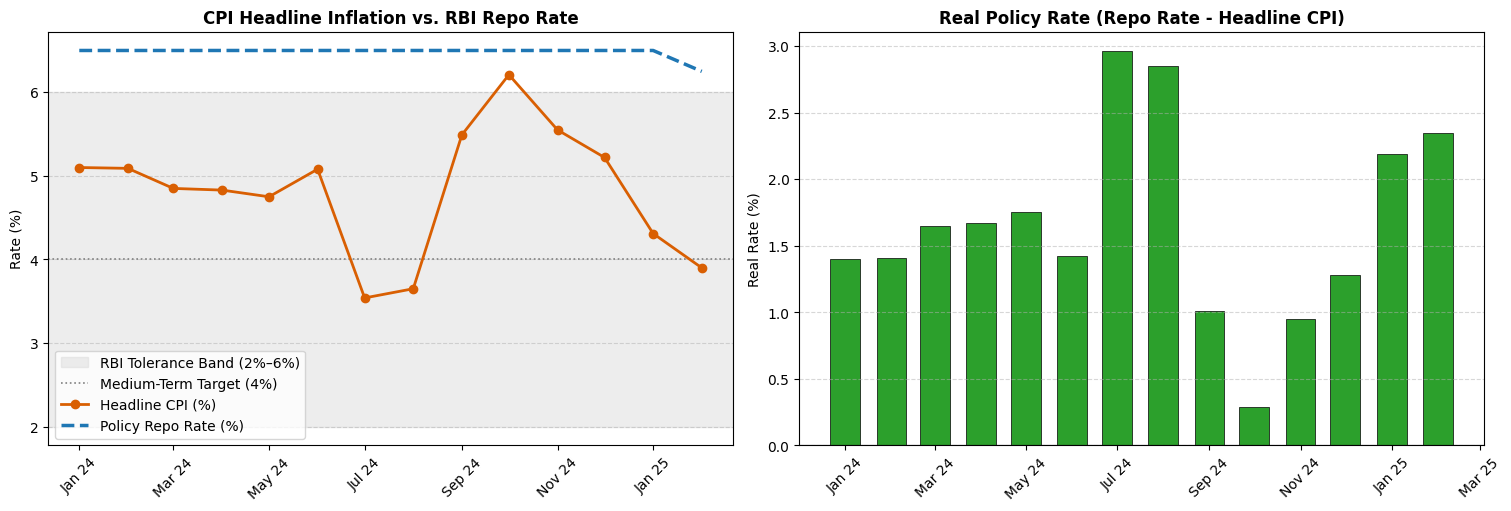

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), layout="constrained")

# --- Chart 1: Headline CPI vs Repo Rate with Tolerance Band ---
# Shaded 2% - 6% RBI Tolerance Band
ax1.axhspan(
    2.0,
    6.0,
    color="lightgray",
    alpha=0.4,
    label="RBI Tolerance Band (2%–6%)",
)
ax1.axhline(
    4.0,
    color="gray",
    linestyle=":",
    linewidth=1.2,
    label="Medium-Term Target (4%)",
)

# Plot lines
ax1.plot(
    df_macro["Month"],
    df_macro["Headline_CPI"],
    color="#d95f02",
    linewidth=2,
    marker="o",
    label="Headline CPI (%)",
)
ax1.plot(
    df_macro["Month"],
    df_macro["Repo_Rate"],
    color="#1f77b4",
    linewidth=2.5,
    linestyle="--",
    label="Policy Repo Rate (%)",
)

ax1.set_title(
    "CPI Headline Inflation vs. RBI Repo Rate", fontsize=12, weight="bold"
)
ax1.set_ylabel("Rate (%)")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
ax1.tick_params(axis="x", rotation=45)
ax1.legend(loc="lower left")
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# --- Chart 2: Real Interest Rate Trajectory ---
colors = [
    "#2ca02c" if rate >= 0 else "#d62728"
    for rate in df_macro["Real_Policy_Rate"]
]
ax2.bar(
    df_macro["Month"],
    df_macro["Real_Policy_Rate"],
    color=colors,
    width=20,
    edgecolor="black",
    linewidth=0.5,
)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title(
    "Real Policy Rate (Repo Rate - Headline CPI)", fontsize=12, weight="bold"
)
ax2.set_ylabel("Real Rate (%)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()